In [ ]:
# Import Library yang dibutuhkan

import pandas as pd
import numpy as np

print ("Pandas Siap dipakai, versi:" , pd.__version__)


Pandas Siap dipakai, versi: 2.2.3


In [ ]:
#Link Google Sheets, versi Export CSV

url_data = "https://docs.google.com/spreadsheets/d/1GuFkH44urw4ACqt5gsWhi1Scei0pGS2L/export?format=csv"

df = pd.read_csv(url_data)

print("Data berhasil di-load!")
print("Jumlah baris dan kolom:", df.shape)

Data berhasil di-load!
Jumlah baris dan kolom: (10000, 16)


In [ ]:
df =pd.read_csv(url_data)
df.shape

(10000, 16)

In [ ]:
print("Nama-nama kolom:")
print(df.columns.tolist())

Nama-nama kolom:
['sales_date', 'order_id', 'customer_name', 'branch', 'product_name', 'category', 'color', 'price', 'quantity', 'payment_type', 'trade_in', 'discount', 'total', 'total_sales', 'status', 'branch_address']


In [ ]:
print("10 baris pertama :")
print(df.head(10))

10 baris pertama :
   sales_date  order_id  customer_name     branch  \
0  2025-12-13  TRX00001   Customer_913    Jakarta   
1  2025-10-15  TRX00002   Customer_261    Jakarta   
2  2025-01-04  TRX00003  Customer_4465    Kendari   
3  2025-02-17  TRX00004  Customer_2788     Padang   
4  2025-10-02  TRX00005  Customer_2941   Karawang   
5  2025-07-05  TRX00006  Customer_3101    Bandung   
6  2025-02-21  TRX00007   Customer_570    Jakarta   
7  2025-12-16  TRX00008  Customer_2989  Pontianak   
8  2025-11-24  TRX00009  Customer_1402   Semarang   
9  2025-07-25  TRX00010  Customer_1800   Karawang   

                           product_name       category           color  \
0              Daihatsu Xenia 1.5 R CVT            MPV  Silver Metalik   
1        Toyota Rush 1.5 S GR Sport CVT            SUV   Hitam Metalik   
2                  Honda BR-V 1.5 E CVT            MPV           Merah   
3                Honda Brio Satya E CVT      Hatchback           Merah   
4       Isuzu D-Max Double 

In [ ]:
# Hitung Jumlah Transaksi perkategori mobil

Jumlah_Transaksi = df['category'].value_counts()
print (Jumlah_Transaksi)

category
SUV              4565
MPV              3915
Hatchback         519
Pickup            516
City Car (EV)     485
Name: count, dtype: int64


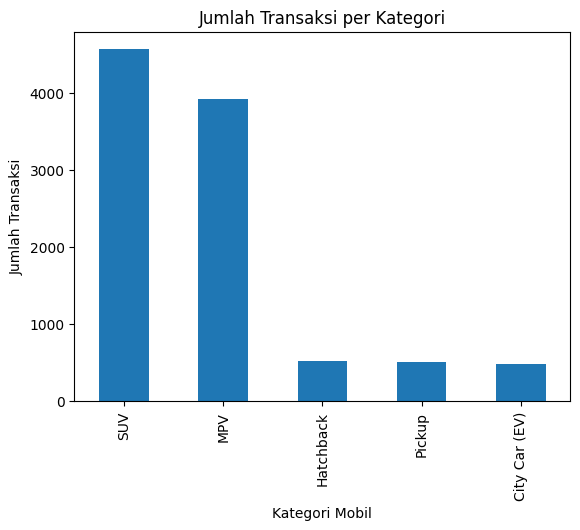

In [ ]:
# Bar Chart Jumlah transaksi terbanyak per kategori

import matplotlib.pyplot as plt

jumlah_transaksi = df["category"].value_counts()

jumlah_transaksi.plot(kind="bar")

plt.title("Jumlah Transaksi per Kategori")
plt.xlabel("Kategori Mobil")
plt.ylabel("Jumlah Transaksi")
plt.show()

In [ ]:
# Jumlah transaksi percabang, urutkan dari yang terbesar

jumlah_transaksi = df["branch"].value_counts().sort_values(ascending=False)

print(jumlah_transaksi)

branch
Jakarta      1058
Padang       1044
Malang       1044
Bandung       989
Batam         986
Pontianak     982
Palembang     981
Kendari       976
Karawang      973
Semarang      967
Name: count, dtype: int64


In [ ]:
# Menampilkan Jumlah transaksi terbanyak

cabang_terbanyak = df["branch"].value_counts().idxmax()
jumlah_terbanyak = df["branch"].value_counts().max()

print("Cabang dengan transaksi terbanyak:", cabang_terbanyak)
print("Jumlah transaksi:", jumlah_terbanyak)

Cabang dengan transaksi terbanyak: Jakarta
Jumlah transaksi: 1058


In [ ]:
# Memeriksa Missing value

df.isnull().sum()

,0
sales_date,0
order_id,0
customer_name,0
branch,0
product_name,0
category,0
color,0
price,0
quantity,0
payment_type,0


In [ ]:
df["trade_in"] = df["trade_in"].fillna(0)


In [ ]:
# Cek Duplikat

df.duplicated().sum()

np.int64(0)

In [ ]:
df["order_id"].duplicated().sum()

np.int64(0)

In [ ]:
df["payment_type"] = df["payment_type"].str.strip().str.title()

['Cash + Trade In' 'Kredit' 'Kredit + Trade In' 'Cash']


In [ ]:
# Mengubah Sales date menjadi type data datetime
df["sales_date"] = pd.to_datetime(df["sales_date"])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   sales_date      10000 non-null  datetime64[ns]
 1   order_id        10000 non-null  object        
 2   customer_name   10000 non-null  object        
 3   branch          10000 non-null  object        
 4   product_name    10000 non-null  object        
 5   category        10000 non-null  object        
 6   color           10000 non-null  object        
 7   price           10000 non-null  int64         
 8   quantity        10000 non-null  int64         
 9   payment_type    10000 non-null  object        
 10  trade_in        10000 non-null  int64         
 11  discount        10000 non-null  int64         
 12  total           10000 non-null  int64         
 13  total_sales     10000 non-null  int64         
 14  status          10000 non-null  object        
 15  bra

In [ ]:
# Filter transaksi yang statusnya "completed"

df_completed = df[df["status"] == "completed"]



In [ ]:
# Kelompokkan berdasarkan branch dan category,

pendapatan = df_completed.groupby(["branch", "category"])["total_sales"].sum()
print(pendapatan)


branch     category     
Bandung    City Car (EV)     11647000000
           Hatchback          6602000000
           MPV               88986000000
           Pickup            21927000000
           SUV              149455000000
Batam      City Car (EV)      9629000000
           Hatchback          6661000000
           MPV               85065000000
           Pickup            24797000000
           SUV              151981000000
Jakarta    City Car (EV)     10622000000
           Hatchback          6438000000
           MPV               89184000000
           Pickup            21708000000
           SUV              155749000000
Karawang   City Car (EV)      8205000000
           Hatchback          4318000000
           MPV               85296000000
           Pickup            15979000000
           SUV              150498000000
Kendari    City Car (EV)      6654000000
           Hatchback          5652000000
           MPV               84954000000
           Pickup            281

In [ ]:
# urutkan 5 dari pendapatan terbesar

pendapatan = pendapatan.sort_values(ascending=False)
top_5 = pendapatan.head(5)
print(top_5)


branch     category
Palembang  SUV         157626000000
Jakarta    SUV         155749000000
Malang     SUV         154891000000
Batam      SUV         151981000000
Karawang   SUV         150498000000
Name: total_sales, dtype: int64


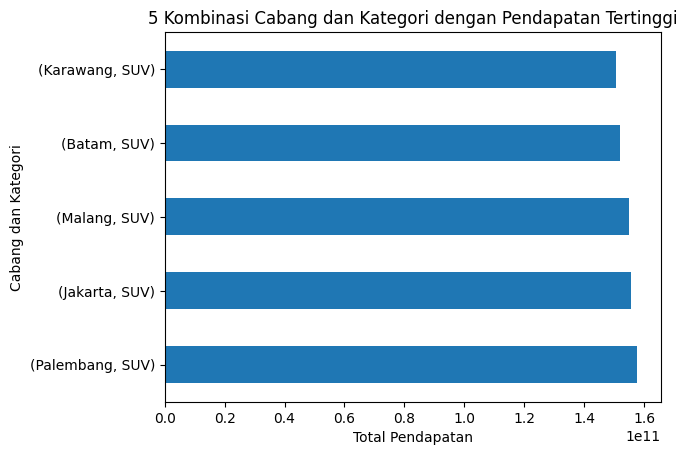

In [ ]:
# Mmebuat Chart Horizontal dari top 5 pendapatan terbesar

import matplotlib.pyplot as plt

top_5.plot(kind="barh")

plt.title("5 Kombinasi Cabang dan Kategori dengan Pendapatan Tertinggi")
plt.xlabel("Total Pendapatan")
plt.ylabel("Cabang dan Kategori")
plt.show()

In [ ]:
# 1. Filter transaksi yang statusnya "completed"

df_completed = df[df["status"] == "completed"]


In [ ]:
# 2. Groupby kombinasi branch dan category, jumlahkan total_sales

pendapatan = df_completed.groupby(["branch", "category"])["total_sales"].sum()


In [ ]:
# 3. Urutkan dari terbesar, ambil 5 kombinasi teratas

top_5 = pendapatan.sort_values(ascending=False).head(5)

print(top_5)

branch     category
Palembang  SUV         157626000000
Jakarta    SUV         155749000000
Malang     SUV         154891000000
Batam      SUV         151981000000
Karawang   SUV         150498000000
Name: total_sales, dtype: int64


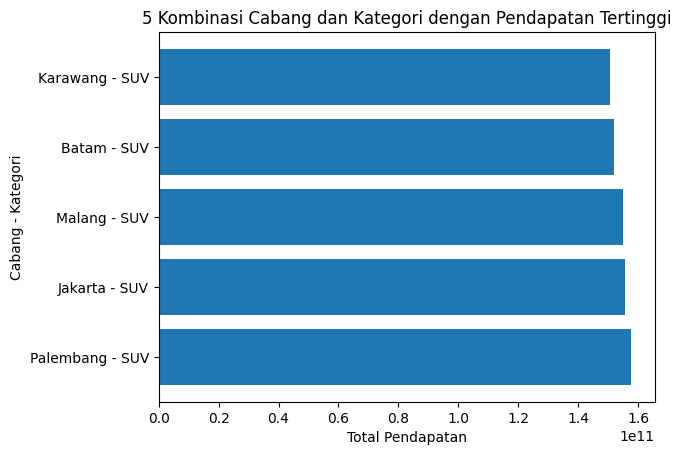

In [ ]:
# 4. Buat bar chart horizontal dari 5 kombinasi teratas
import matplotlib.pyplot as plt

label = top_5.index.map(lambda x: f"{x[0]} - {x[1]}")

plt.barh(label, top_5.values)
plt.title("5 Kombinasi Cabang dan Kategori dengan Pendapatan Tertinggi")
plt.xlabel("Total Pendapatan")
plt.ylabel("Cabang - Kategori")
plt.show()

In [ ]:
# 5. Rata-rata harga per unit untuk 5 kombinasi teratas

rata_rata_harga = df_completed.groupby(["branch", "category"])["price"].mean()

rata_rata_harga_top5 = rata_rata_harga.loc[top_5.index]
print(rata_rata_harga_top5)

branch     category
Palembang  SUV         4.100477e+08
Jakarta    SUV         4.081567e+08
Malang     SUV         4.190441e+08
Batam      SUV         4.144743e+08
Karawang   SUV         4.012864e+08
Name: price, dtype: float64
